In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import os
import seaborn as sns
from nltk.corpus import stopwords
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import GlobalMaxPooling1D
from keras.layers import LSTM
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

import matplotlib.pyplot as plt
import seaborn as sns

For our work, we use the **IMDB dataset**, which contains two columns: a **“review”** column and a column indicating the **sentiment** (negative or positive). The dataset includes **25,000 positive reviews** and **25,000 negative reviews**. We will compare the performance of **three models**: a **simple MLP**, a **CNN**, and an **LSTM**.


Chargement du dataset depuis: IMDB Dataset.csv
Dimension du dataset :  (50000, 2)
Valeurs NULL dans le dataset : 
 review       0
sentiment    0
dtype: int64
Les 5 premières lignes du dataset : 
                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


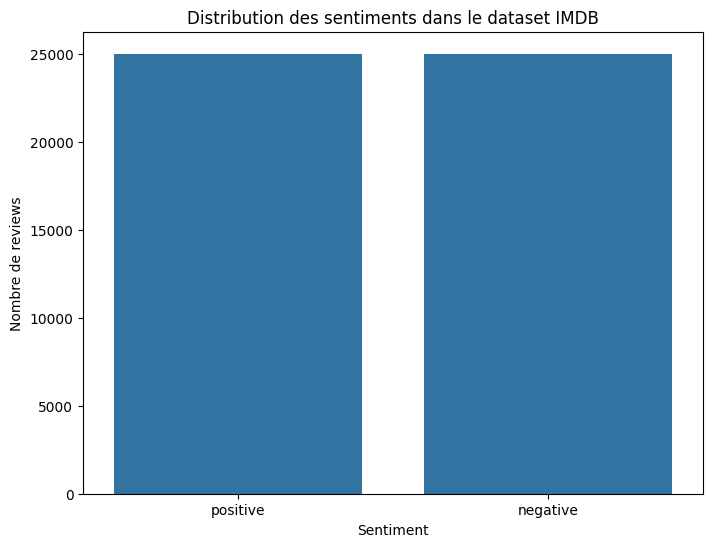


Distribution des sentiments:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Pourcentage:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

--- 4ème review ---
Sentiment: negative
Review text:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.

Lon

In [2]:
# ÉTAPE 1: Importation et exploration du dataset

# Construire le chemin du fichier IMDB
imdb_file_path = "IMDB Dataset.csv"
print(f"Chargement du dataset depuis: {imdb_file_path}")

# Importer le dataset IMDB
imdb_data = pd.read_csv(imdb_file_path)

# Dimension du dataset
print("Dimension du dataset : ", imdb_data.shape)

# Vérification des valeurs NULL
print("Valeurs NULL dans le dataset : \n", imdb_data.isnull().sum())

# Affichage des 5 premières lignes
print("Les 5 premières lignes du dataset : \n", imdb_data.head())

# Vérifier si le dataset est équilibré avec countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=imdb_data, x='sentiment')
plt.title('Distribution des sentiments dans le dataset IMDB')
plt.xlabel('Sentiment')
plt.ylabel('Nombre de reviews')
plt.show()

# Afficher les comptages exacts
print("\nDistribution des sentiments:")
print(imdb_data['sentiment'].value_counts())
print("\nPourcentage:")
print(imdb_data['sentiment'].value_counts(normalize=True) * 100)

# Afficher le 4ème review (index 3 car Python est 0-indexé)
print("\n--- 4ème review ---")
print("Sentiment:", imdb_data['sentiment'][3])
print("Review text:")
print(imdb_data['review'][3])
print("\nLongueur du review:", len(imdb_data['review'][3]), "caractères")

First, we **clean the dataset** by removing elements that do not provide useful information (**HTML tags, numbers, punctuation, and multiple spaces**). This process **reduces sentence length and decreases noise** in the data. As a result, we obtain **cleaner sentences that are better suited for training**.


In [3]:
def preprocess_text(sen):
    # Étape 1: Supprimer les balises HTML (ex: <br />, <html>, etc.)
    sentence = remove_tags(sen)

    # Étape 2: Supprimer tout sauf les lettres (a-z, A-Z)

    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Étape 3: Supprimer les caractères isolés (un seul caractère entouré d'espaces)
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Étape 4: Remplacer les espaces multiples par un seul espace
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

# Expression régulière pour trouver les balises HTML
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)  # Remplace les balises par une chaîne vide

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# Chargement des données (si pas déjà fait)
imdb_data = pd.read_csv(imdb_file_path)

# Définition des fonctions de prétraitement
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    """Supprime les balises HTML"""
    return TAG_RE.sub('', text)

def preprocess_text(sen):
    """Nettoie complètement un review"""
    # Supprimer les balises HTML
    sentence = remove_tags(sen)

    # Supprimer les chiffres et ponctuations, ne garder que les lettres
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Supprimer les caractères isolés (un seul caractère)
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Supprimer les espaces multiples
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence.strip()  # strip() enlève les espaces au début/fin

# Prétraiter tous les reviews
X = []
sentences = list(imdb_data['review'])

print("Prétraitement en cours...")
for i, sen in enumerate(sentences):
    X.append(preprocess_text(sen))
    if (i + 1) % 10000 == 0:
        print(f"{i+1} reviews traités sur {len(sentences)}")

print(f"\nPrétraitement terminé! {len(X)} reviews traités.")

Prétraitement en cours...
10000 reviews traités sur 50000
20000 reviews traités sur 50000
30000 reviews traités sur 50000
40000 reviews traités sur 50000
50000 reviews traités sur 50000

Prétraitement terminé! 50000 reviews traités.


In [6]:
# Afficher le 4ème review avant et après prétraitement
print("="*70)
print("4ÈME REVIEW - COMPARAISON AVANT/APRÈS PRÉTRAITEMENT")
print("="*70)

print("\n--- AVANT PRÉTRAITEMENT ---")
print(f"Texte original: {imdb_data['review'][3]}")
print(f"Longueur: {len(imdb_data['review'][3])} caractères")

print("\n--- APRÈS PRÉTRAITEMENT ---")
print(f"Texte nettoyé: {X[3]}")
print(f"Longueur: {len(X[3])} caractères")

# Analyse des changements
print("\n--- OBSERVATIONS ---")
observations = {
    "Balises HTML": "Les <br /><br /> ont été supprimés",
    "Ponctuation": "Les points, virgules, ? ! etc. ont été supprimés",
    "Chiffres": "Le '3 out of 10' est devenu 'out of' (les chiffres sont supprimés)",
    "Caractères isolés": "Les lettres seules comme 'a' ont été supprimées",
    "Contractions": "'there's' est devenu 'theres' (l'apostrophe supprimée)",
    "Majuscules": "Tout est en minuscules maintenant",
    "Mots": "Le texte est maintenant une séquence de mots séparés par un espace"
}

for key, value in observations.items():
    print(f"• {key}: {value}")

4ÈME REVIEW - COMPARAISON AVANT/APRÈS PRÉTRAITEMENT

--- AVANT PRÉTRAITEMENT ---
Texte original: Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.
Longueur: 748 caractères

--- APRÈS PRÉTRAITEMENT ---
Texte nettoyé: Basically there a family where little boy Jake thinks there a zombie in his closet hi

Next, since the models can only process numerical values, we transform the “sentiment” column: 0 for negative and 1 for positive. We then split the dataset into a training set (80%) and a test set (20%).


In [5]:
# Convertir les sentiments en nombres
y = imdb_data['sentiment']
y = np.array(list(map(lambda x: 1 if x == "positive" else 0, y)))

print("\n--- CONVERSION DES ÉTIQUETTES ---")
print(f"Type de y: {type(y)}")
print(f"Shape de y: {y.shape}")
print(f"Valeurs uniques: {np.unique(y)}")
print(f"Nombre de positifs (1): {np.sum(y == 1)}")
print(f"Nombre de négatifs (0): {np.sum(y == 0)}")
print(f"Distribution: {np.sum(y == 1)/len(y)*100:.1f}% positifs, {np.sum(y == 0)/len(y)*100:.1f}% négatifs")


--- CONVERSION DES ÉTIQUETTES ---
Type de y: <class 'numpy.ndarray'>
Shape de y: (50000,)
Valeurs uniques: [0 1]
Nombre de positifs (1): 25000
Nombre de négatifs (0): 25000
Distribution: 50.0% positifs, 50.0% négatifs


**Split the dataset into 20% test data and 80% training data.**


In [7]:
# Division du dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,  # 20% pour le test, 80% pour l'entraînement
    random_state=42  # Pour la reproductibilité
)

print("\n--- DIVISION DES DONNÉES ---")
print(f"X_train: {len(X_train)} reviews")
print(f"X_test: {len(X_test)} reviews")
print(f"y_train: {len(y_train)} étiquettes")
print(f"y_test: {len(y_test)} étiquettes")

# Vérifier la distribution dans train et test
print(f"\nDistribution dans train: {np.sum(y_train==1)/len(y_train)*100:.1f}% positifs")
print(f"Distribution dans test: {np.sum(y_test==1)/len(y_test)*100:.1f}% positifs")



--- DIVISION DES DONNÉES ---
X_train: 40000 reviews
X_test: 10000 reviews
y_train: 40000 étiquettes
y_test: 10000 étiquettes

Distribution dans train: 49.9% positifs
Distribution dans test: 50.4% positifs


To convert the reviews into **numerical values**, we first perform **tokenization**: we split the sentences into words and then compute the **frequency of each word**. The most frequent word is assigned **index 1**, and so on.

Next, we transform these words into **vectors of dimension 100**. This choice (**embedding size = 100**) represents a good trade-off between **semantic richness** and **computational complexity**.

To achieve this, we use **GloVe**, a **pre-trained model** trained on large-scale internet data, which associates each word with a vector (similar to a **dictionary that maps words to vectors**).

An **embedding matrix** is then created, where **each word corresponds to a vector of 100 numerical values**.


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from numpy import zeros, asarray
import numpy as np
import os


glove_file_path = "glove.6B.100d.txt"

# Création du dictionnaire word-to-index avec Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Padding des séquences
maxlen = 100
X_train_padded = pad_sequences(X_train_sequences, padding='post', maxlen=maxlen)
X_test_padded = pad_sequences(X_test_sequences, padding='post', maxlen=maxlen)

# Taille du vocabulaire
vocab_size = len(tokenizer.word_index) + 1

print("=== INFORMATION SUR LES FICHIERS GLOVE ===")
print(f"vocab_size: {vocab_size}")

# Chargement et filtrage des embeddings GloVe
print("\n--- CHARGEMENT ET FILTRAGE DES EMBEDDINGS GLOVE ---")
embeddings_dictionary = dict()
expected_dim = 100
invalid_lines = 0
valid_words = 0

with open(glove_file_path, encoding="utf8") as glove_file:
    for line_num, line in enumerate(glove_file):
        records = line.split()
        if len(records) < 2:
            invalid_lines += 1
            continue

        word = records[0]
        try:
            vector_dimensions = asarray(records[1:], dtype='float32')

            # Vérifier la dimension
            if len(vector_dimensions) == expected_dim:
                embeddings_dictionary[word] = vector_dimensions
                valid_words += 1
            else:
                invalid_lines += 1
                if invalid_lines <= 5:
                    print(f"  Ligne {line_num}: '{word}' a dimension {len(vector_dimensions)} (attendu: {expected_dim})")
        except:
            invalid_lines += 1

        if valid_words % 50000 == 0 and valid_words > 0:
            print(f"  Chargé {valid_words} mots valides...")

print(f"\n✓ Mots valides chargés: {valid_words}")
print(f"✓ Lignes invalides ignorées: {invalid_lines}")

# Création de la matrice d'embeddings avec gestion des erreurs
print("\n--- CRÉATION DE LA MATRICE D'EMBEDDING ---")
embedding_matrix = zeros((vocab_size, expected_dim))
words_found = 0
words_not_found = 0
dimension_errors = 0

for word, index in tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        try:
            if len(embedding_vector) == expected_dim:
                embedding_matrix[index] = embedding_vector
                words_found += 1
            else:
                dimension_errors += 1
        except:
            dimension_errors += 1
    else:
        words_not_found += 1

    if index % 10000 == 0 and index > 0:
        print(f"  Traitement des mots: {index}/{vocab_size-1}")

print(f"\n--- STATISTIQUES FINALES ---")
print(f"Mots trouvés dans GloVe: {words_found}")
print(f"Mots non trouvés dans GloVe: {words_not_found}")
print(f"Erreurs de dimension: {dimension_errors}")
print(f"Taux de couverture: {words_found/(words_found+words_not_found)*100:.2f}%")
print(f"Forme de embedding_matrix: {embedding_matrix.shape}")

=== INFORMATION SUR LES FICHIERS GLOVE ===
vocab_size: 92547

--- CHARGEMENT ET FILTRAGE DES EMBEDDINGS GLOVE ---
  Chargé 50000 mots valides...
  Chargé 100000 mots valides...
  Chargé 150000 mots valides...
  Chargé 200000 mots valides...
  Chargé 250000 mots valides...
  Chargé 300000 mots valides...
  Chargé 350000 mots valides...
  Chargé 400000 mots valides...

✓ Mots valides chargés: 400000
✓ Lignes invalides ignorées: 0

--- CRÉATION DE LA MATRICE D'EMBEDDING ---
  Traitement des mots: 10000/92546
  Traitement des mots: 20000/92546
  Traitement des mots: 30000/92546
  Traitement des mots: 40000/92546
  Traitement des mots: 50000/92546
  Traitement des mots: 60000/92546
  Traitement des mots: 70000/92546
  Traitement des mots: 80000/92546
  Traitement des mots: 90000/92546

--- STATISTIQUES FINALES ---
Mots trouvés dans GloVe: 69920
Mots non trouvés dans GloVe: 22626
Erreurs de dimension: 0
Taux de couverture: 75.55%
Forme de embedding_matrix: (92547, 100)


**First model: MLP**

This model consists of **three layers**. The first one is an **embedding layer**, which converts each word index into a **100-dimensional vector**, producing a matrix (with word indices and their corresponding vectors).

The next layer, **Flatten**, reshapes this matrix into a **single 1D vector**, since the dense layer cannot process matrices directly and requires a vector input.

Finally, a **dense layer** is used for **classification**.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("CLASSIFICATION AVEC UN RÉSEAU DE NEURONES SIMPLE (DENSE)")
print("="*60)

# Création du modèle
model = Sequential()

# Couche 1: Embedding
model.add(Embedding(
    vocab_size,          # Taille du vocabulaire
    100,                 # Dimension de sortie
    weights=[embedding_matrix],  # Poids GloVe pré-entraînés
    input_length=maxlen,         # Longueur d'entrée
    trainable=False     # On fige les embeddings
))

# Couche 2: Flatten
model.add(Flatten())

# Couche 3: Dense
model.add(Dense(1, activation='sigmoid'))

# Compilation
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

# Affichage de l'architecture
print("\nArchitecture du modèle:")
model.summary()

# Entraînement
print("\nDébut de l'entraînement...")
print("-"*60)

history = model.fit(
    X_train_padded, y_train,
    epochs=6,
    batch_size=128,
    verbose=1,
    validation_split=0.2
)


CLASSIFICATION AVEC UN RÉSEAU DE NEURONES SIMPLE (DENSE)


C:\Users\MSI\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Architecture du modèle:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)


Début de l'entraînement...
------------------------------------------------------------
Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6227 - loss: 0.6514 - val_acc: 0.7253 - val_loss: 0.5392
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7664 - loss: 0.4906 - val_acc: 0.7444 - val_loss: 0.5220
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7975 - loss: 0.4488 - val_acc: 0.7455 - val_loss: 0.5244
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8090 - loss: 0.4244 - val_acc: 0.7475 - val_loss: 0.5230
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8194 - loss: 0.4053 - val_acc: 0.7448 - val_loss: 0.5283
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8288 - loss: 0.3913 - val_acc: 0.7441 - val_loss: 0.5311


Evaluation on the test set


In [11]:
print("\n" + "="*60)
print("ÉVALUATION DU MODÈLE")
print("="*60)

# Évaluation sur l'ensemble de test
score = model.evaluate(X_test_padded, y_test, verbose=1)

print(f"\nTest Score (Loss): {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f} ({score[1]*100:.2f}%)")


ÉVALUATION DU MODÈLE
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7393 - loss: 0.5344

Test Score (Loss): 0.5320
Test Accuracy: 0.7429 (74.29%)


Accuracy & Loss



VISUALISATION DES COURBES D'APPRENTISSAGE


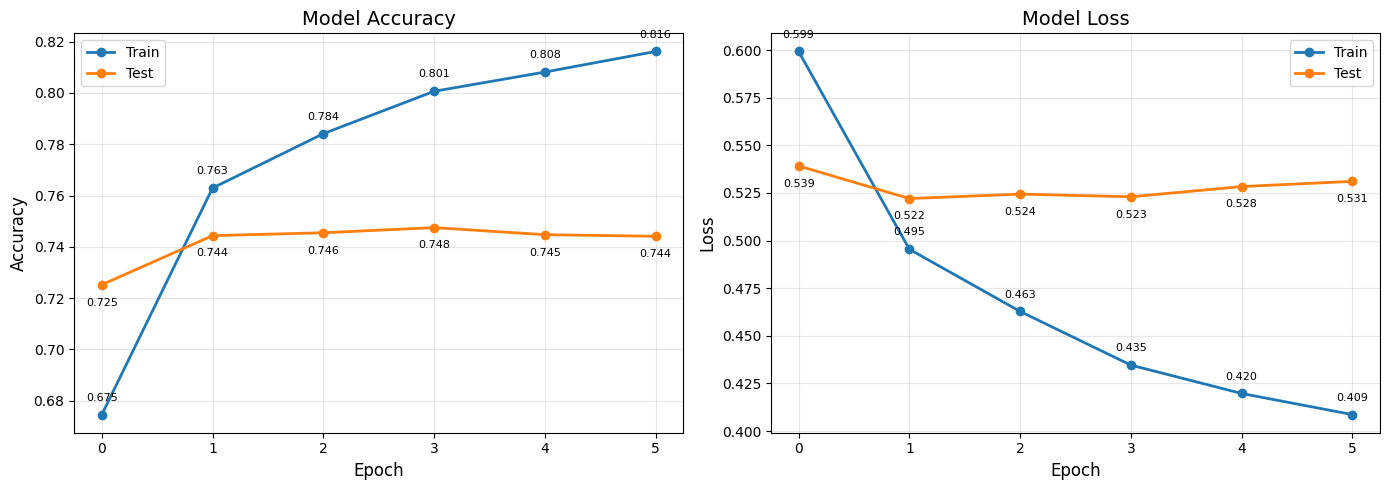

In [12]:
print("\n" + "="*60)
print("VISUALISATION DES COURBES D'APPRENTISSAGE")
print("="*60)

# Création d'une figure avec deux sous-graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Accuracy
ax1.plot(history.history['acc'], label='Train', marker='o', linewidth=2)
ax1.plot(history.history['val_acc'], label='Test', marker='o', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.legend(['Train', 'Test'], loc='upper left')
ax1.grid(True, alpha=0.3)

# Ajouter les valeurs sur les points
for epoch, (train_acc, val_acc) in enumerate(zip(history.history['acc'], history.history['val_acc'])):
    ax1.annotate(f'{train_acc:.3f}', (epoch, train_acc), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    ax1.annotate(f'{val_acc:.3f}', (epoch, val_acc), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

# Graphique 2: Loss
ax2.plot(history.history['loss'], label='Train', marker='o', linewidth=2)
ax2.plot(history.history['val_loss'], label='Test', marker='o', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.legend(['Train', 'Test'], loc='upper right')
ax2.grid(True, alpha=0.3)

# Ajouter les valeurs sur les points
for epoch, (train_loss, val_loss) in enumerate(zip(history.history['loss'], history.history['val_loss'])):
    ax2.annotate(f'{train_loss:.3f}', (epoch, train_loss), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
    ax2.annotate(f'{val_loss:.3f}', (epoch, val_loss), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

We observe that the **training accuracy** is higher than the **test accuracy**, whereas the **loss behaves in the opposite way**. These results suggest that the model is experiencing **overfitting**.

### 1. **Overfitting**

- Training accuracy increases (66% → 81%)
- Test accuracy remains almost stable (~73%)
- The model is memorizing training data instead of generalizing

### 2. **Best performance at Epoch 2**

- Maximum test accuracy: **73.2%**
- After Epoch 2, performance does not improve

### 3. **Growing train-test gap**

- Epoch 1: train (66%) < test (72%)
- Epoch 6: train (81%) > test (73%)
- Clear sign of overfitting

### 4. **Explanation**

The next layer, **Flatten**, converts the matrix into a single **1D vector**. The problem is that the **Dense layer no longer preserves the temporal structure** of the sequence. We end up with a global vector where information from all words is mixed together.

As a result, the model cannot distinguish which word comes before another, nor capture relationships between words, meaning it loses all **contextual information**.

This leads to **overfitting**, mainly due to the very large number of parameters in the Dense layer. Each connection between neurons represents a weight to learn, and with thousands of words, the number of parameters grows significantly, making the model prone to memorizing the training data instead of generalizing.

### 5. **Conclusion**

- The Dense (MLP) model is too simple for this task
- More suitable models like **CNNs or LSTMs** are needed to better capture sentence context


**Second model: CNN**

This model consists of **four layers**: an **embedding layer**, a **Conv1D layer**, a **MaxPooling layer**, and finally a **dense layer**.

The **Conv1D layer** acts on local regions of the text by analyzing groups of **5 words at a time**, allowing the model to capture **local context** such as expressions like _“not good”_ or _“very bad”_.

The **MaxPooling layer** then reduces the sequence length by keeping only the most important features, which helps to simplify the representation while preserving key information.

Finally, the **dense layer** performs the **classification**.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Dense, Flatten

# Création du modèle CNN
model_cnn = Sequential()

# Couche 1: Embedding
model_cnn.add(Embedding(vocab_size, 100, weights=[embedding_matrix],
                        input_length=maxlen, trainable=False))

# Couche 2: Conv1D
model_cnn.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Couche 3: MaxPooling1D
model_cnn.add(MaxPooling1D(pool_size=2))

# Couche 4: Dense (sortie)
model_cnn.add(Flatten())
model_cnn.add(Dense(1, activation='sigmoid'))

# Compilation
model_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Affichage
model_cnn.summary()

# Entraînement
history_cnn = model_cnn.fit(X_train_padded, y_train,
                            epochs=6, batch_size=128,
                            verbose=1, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - acc: 0.6340 - loss: 0.6331 - val_acc: 0.7436 - val_loss: 0.5064
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 0.7927 - loss: 0.4406 - val_acc: 0.8066 - val_loss: 0.4243
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - acc: 0.8370 - loss: 0.3718 - val_acc: 0.7928 - val_loss: 0.4364
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.8716 - loss: 0.3122 - val_acc: 0.8020 - val_loss: 0.4301
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 0.8975 - loss: 0.2593 - val_acc: 0.8154 - val_loss: 0.4169
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - acc: 0.9304 - loss: 0.1998 - val_acc: 0.8087 - val_loss: 0.4268


In [14]:
# Évaluation
score_cnn = model_cnn.evaluate(X_test_padded, y_test, verbose=1)
print(f"Test Loss: {score_cnn[0]:.4f}")
print(f"Test Accuracy: {score_cnn[1]:.4f} ({score_cnn[1]*100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8108 - loss: 0.4359
Test Loss: 0.4316
Test Accuracy: 0.8097 (80.97%)


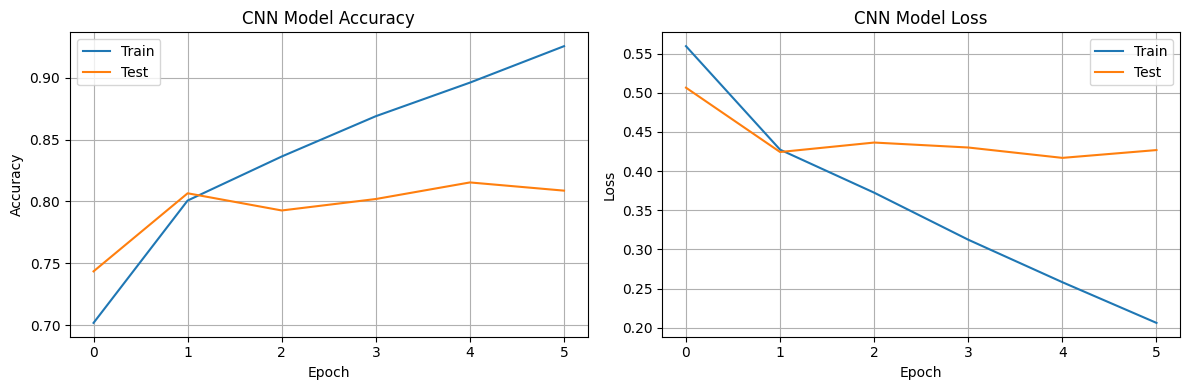

In [15]:
import matplotlib.pyplot as plt

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history_cnn.history['acc'], label='Train')
ax1.plot(history_cnn.history['val_acc'], label='Test')
ax1.set_title('CNN Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history_cnn.history['loss'], label='Train')
ax2.plot(history_cnn.history['val_loss'], label='Test')
ax2.set_title('CNN Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

The CNN performs better than the MLP because it is able to detect **local patterns between words**, which improves its understanding of short expressions and contextual phrases.

However, a **slight overfitting issue still remains**, as the model sometimes learns patterns that are too specific to the training dataset and does not generalize well enough to unseen data.

**Therefore, the CNN is not retained as the final model**, since the overfitting problem is still present.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Création du modèle LSTM
model_lstm = Sequential()

# Couche 1: Embedding
model_lstm.add(Embedding(vocab_size, 100,
                         weights=[embedding_matrix],
                         input_length=maxlen,
                         trainable=False))

# Couche 2: LSTM
model_lstm.add(LSTM(units=128))

# Couche 3: Dense (sortie)
model_lstm.add(Dense(1, activation='sigmoid'))

# Compilation
model_lstm.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['acc'])

# Affichage
model_lstm.summary()

# Entraînement
history_lstm = model_lstm.fit(X_train_padded, y_train,
                              epochs=6,
                              batch_size=128,
                              verbose=1,
                              validation_split=0.2)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     9,254,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,254,700 (35.30 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,254,700 (35.30 MB)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - acc: 0.6469 - loss: 0.6115 - val_acc: 0.7805 - val_loss: 0.4693
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 37s 146ms/step - acc: 0.7856 - loss: 0.4584 - val_acc: 0.8095 - val_loss: 0.4320
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - acc: 0.8210 - loss: 0.3953 - val_acc: 0.8336 - val_loss: 0.3710
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - acc: 0.8377 - loss: 0.3652 - val_acc: 0.8484 - val_loss: 0.3496
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 250ms/step - acc: 0.8516 - loss: 0.3381 - val_acc: 0.8503 - val_loss: 0.3392
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 262ms/step - acc: 0.8619 - loss: 0.3181 - val_acc: 0.8384 - val_loss: 0.3688


In [17]:
# Évaluation
score_lstm = model_lstm.evaluate(X_test_padded, y_test, verbose=1)
print(f"Test Loss: {score_lstm[0]:.4f}")
print(f"Test Accuracy: {score_lstm[1]:.4f} ({score_lstm[1]*100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - acc: 0.8326 - loss: 0.3699
Test Loss: 0.3649
Test Accuracy: 0.8365 (83.65%)


**Third model: LSTM**

This model consists of **three layers**: an **embedding layer**, an **LSTM layer (128 memory units)**, and finally a **dense layer**.

The **LSTM layer** is designed to capture **long-term dependencies** in the text by remembering important information across the sequence of words, which helps preserve context over longer sentences.

The final **dense layer** performs the **classification task** based on the learned sequential representations.


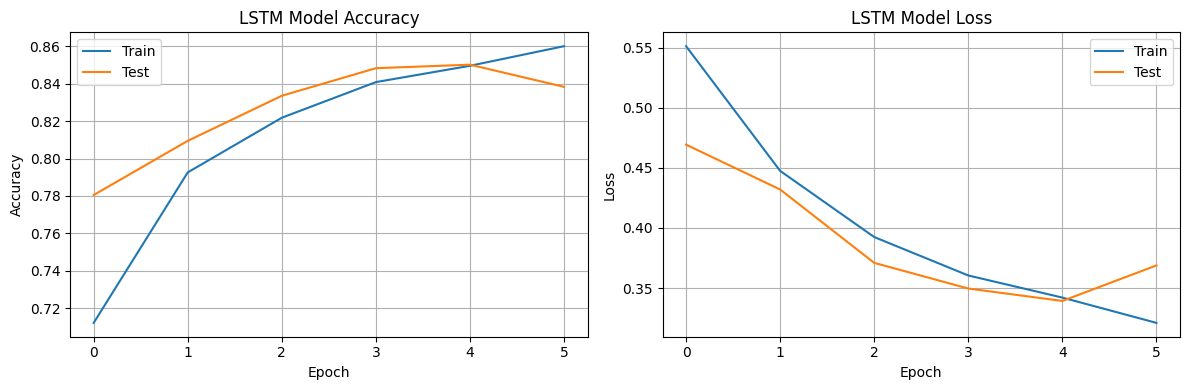

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history_lstm.history['acc'], label='Train')
ax1.plot(history_lstm.history['val_acc'], label='Test')
ax1.set_title('LSTM Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history_lstm.history['loss'], label='Train')
ax2.plot(history_lstm.history['val_loss'], label='Test')
ax2.set_title('LSTM Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

We observe that there is **no significant overfitting with the LSTM model**, which is mainly due to its ability to **capture long-term dependencies in the text while maintaining the sequential structure of the data**.

Unlike MLP and CNN, the LSTM does not rely on flattening or purely local feature extraction. Instead, its **memory mechanism (gates and hidden states)** allows it to **retain relevant contextual information across the entire sentence**, reducing the tendency to memorize training-specific patterns.

In addition, the LSTM’s architecture is generally more **regularized in practice for sequence learning**, which helps it generalize better on unseen data.


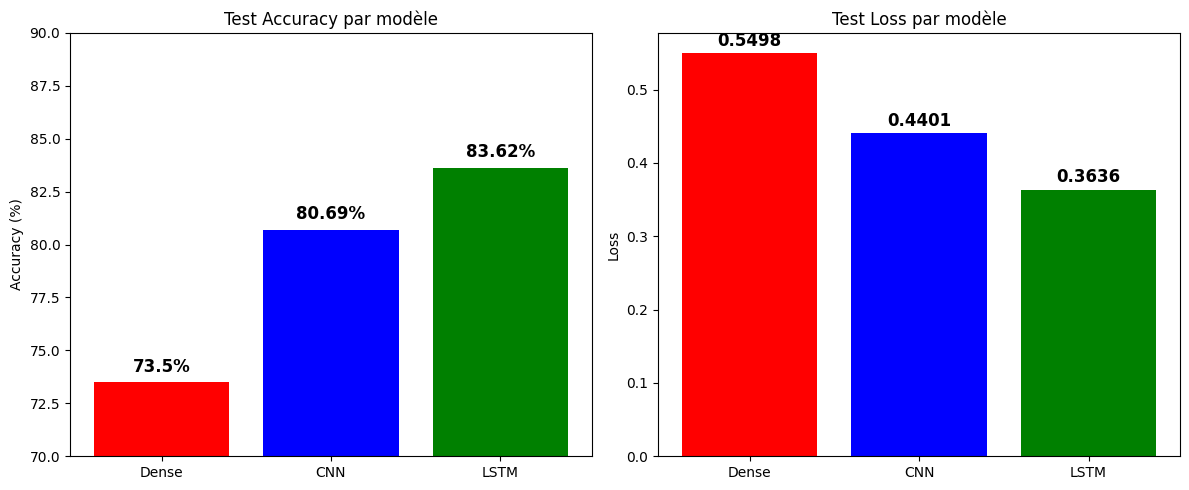

In [19]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Dense', 'CNN', 'LSTM']
test_acc = [73.50, 80.69, 83.62]
test_loss = [0.5498, 0.4401, 0.3636]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
bars1 = ax1.bar(models, test_acc, color=['red', 'blue', 'green'])
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy par modèle')
ax1.set_ylim(70, 90)
for bar, acc in zip(bars1, test_acc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc}%', ha='center', fontsize=12, fontweight='bold')

# Loss
bars2 = ax2.bar(models, test_loss, color=['red', 'blue', 'green'])
ax2.set_ylabel('Loss')
ax2.set_title('Test Loss par modèle')
for bar, loss in zip(bars2, test_loss):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{loss}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()